# Heart Disease Prediction — ML Group Project

**Dataset:** `heart disease.csv` — 630,000 records, 14 features + 1 target  
**Target:** `Heart Disease` (Presence / Absence)  

---

## Table of Contents
1. [Imports & Data Loading](#1)
2. [Initial Sense Check](#2)
3. [Target Variable Analysis](#3)
4. [Feature Distributions](#4)
5. [Correlation Analysis](#5)
6. [Bivariate Analysis — Features vs Target](#6)
7. [Outlier Detection](#7)
8. [Key EDA Takeaways](#8)

## 1. Imports & Data Loading <a id="1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv("heart disease.csv")

# Encode target as binary integer for numeric operations (keep original column too)
df["target"] = (df["Heart Disease"] == "Presence").astype(int)

# Rename columns to snake_case for convenience
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
# Restore the binary target name after rename
df = df.rename(columns={"heart_disease": "heart_disease", "target": "target"})

print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded 630,000 rows × 16 columns


,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease,target
0,0,58,1,4,152,239,0,0,158,1,3.60,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.00,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.00,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.00,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.80,2,3,3,Presence,1


## 2. Initial Sense Check <a id="2"></a>

In [3]:
# --- Shape & dtypes ---
print("=== Shape ===")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns\n")

print("=== Column names & dtypes ===")
print(df.dtypes.to_string())


=== Shape ===
630,000 rows, 16 columns

=== Column names & dtypes ===
id                           int64
age                          int64
sex                          int64
chest_pain_type              int64
bp                           int64
cholesterol                  int64
fbs_over_120                 int64
ekg_results                  int64
max_hr                       int64
exercise_angina              int64
st_depression              float64
slope_of_st                  int64
number_of_vessels_fluro      int64
thallium                     int64
heart_disease               object
target                       int64


In [4]:
# --- Missing values ---
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "%": missing_pct})
print(missing_df[missing_df["count"] > 0].to_string() if missing_df["count"].sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [5]:
# --- Duplicates ---
n_dups = df.duplicated().sum()
print(f"=== Duplicate Rows ===")
print(f"{n_dups:,} exact duplicate rows ({n_dups/len(df)*100:.2f}%)")

# Drop duplicates if any
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")

=== Duplicate Rows ===
0 exact duplicate rows (0.00%)


In [6]:
# --- Descriptive statistics ---
print("=== Descriptive Statistics (numeric features) ===")
# Exclude id and target from the stats display
stat_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["id", "target"]]
df[stat_cols].describe().T.style.background_gradient(cmap="Blues", axis=1)

=== Descriptive Statistics (numeric features) ===


,count,mean,std,min,25%,50%,75%,max
age,630000.000000,54.136706,8.256301,29.000000,48.000000,54.000000,60.000000,77.000000
sex,630000.000000,0.714735,0.451541,0.000000,0.000000,1.000000,1.000000,1.000000
chest_pain_type,630000.000000,3.312752,0.851615,1.000000,3.000000,4.000000,4.000000,4.000000
bp,630000.000000,130.497433,14.975802,94.000000,120.000000,130.000000,140.000000,200.000000
cholesterol,630000.000000,245.011814,33.681581,126.000000,223.000000,243.000000,269.000000,564.000000
fbs_over_120,630000.000000,0.079987,0.271274,0.000000,0.000000,0.000000,0.000000,1.000000
ekg_results,630000.000000,0.981660,0.998783,0.000000,0.000000,0.000000,2.000000,2.000000
max_hr,630000.000000,152.816763,19.112927,71.000000,142.000000,157.000000,166.000000,202.000000
exercise_angina,630000.000000,0.273725,0.445870,0.000000,0.000000,0.000000,1.000000,1.000000
st_depression,630000.000000,0.716028,0.948472,0.000000,0.000000,0.100000,1.400000,6.200000


In [7]:
# --- Value ranges sanity check ---
print("=== Feature Value Ranges (sanity check) ===")
range_info = []
for col in stat_cols:
    range_info.append({
        "feature": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "unique_values": df[col].nunique(),
        "zero_count": (df[col] == 0).sum(),
        "negative_count": (df[col] < 0).sum(),
    })
pd.DataFrame(range_info).set_index("feature")

=== Feature Value Ranges (sanity check) ===


,min,max,unique_values,zero_count,negative_count
feature,,,,,
age,29.00,77.00,42,0,0
sex,0.00,1.00,2,179717,0
chest_pain_type,1.00,4.00,4,0,0
bp,94.00,200.00,66,0,0
cholesterol,126.00,564.00,150,0,0
fbs_over_120,0.00,1.00,2,579608,0
ekg_results,0.00,2.00,3,320116,0
max_hr,71.00,202.00,93,0,0
exercise_angina,0.00,1.00,2,457553,0


## 3. Target Variable Analysis <a id="3"></a>

=== Target Distribution ===
  Absence: 347,546  (55.2%)
  Presence: 282,454  (44.8%)


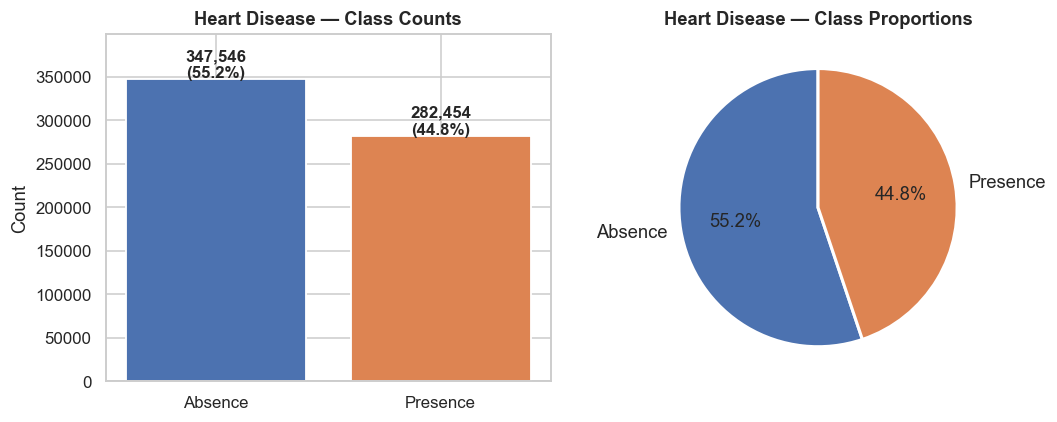

In [8]:
target_counts = df["heart_disease"].value_counts()
target_pct = df["heart_disease"].value_counts(normalize=True) * 100

print("=== Target Distribution ===")
for label, count in target_counts.items():
    print(f"  {label}: {count:,}  ({target_pct[label]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
colors = ["#4C72B0", "#DD8452"]
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor="white", linewidth=1.2)
for i, (label, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 1500, f"{count:,}\n({target_pct[label]:.1f}%)", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Heart Disease — Class Counts", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, target_counts.max() * 1.15)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 12})
axes[1].set_title("Heart Disease — Class Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Feature Distributions <a id="4"></a>

### 4a. Continuous Features

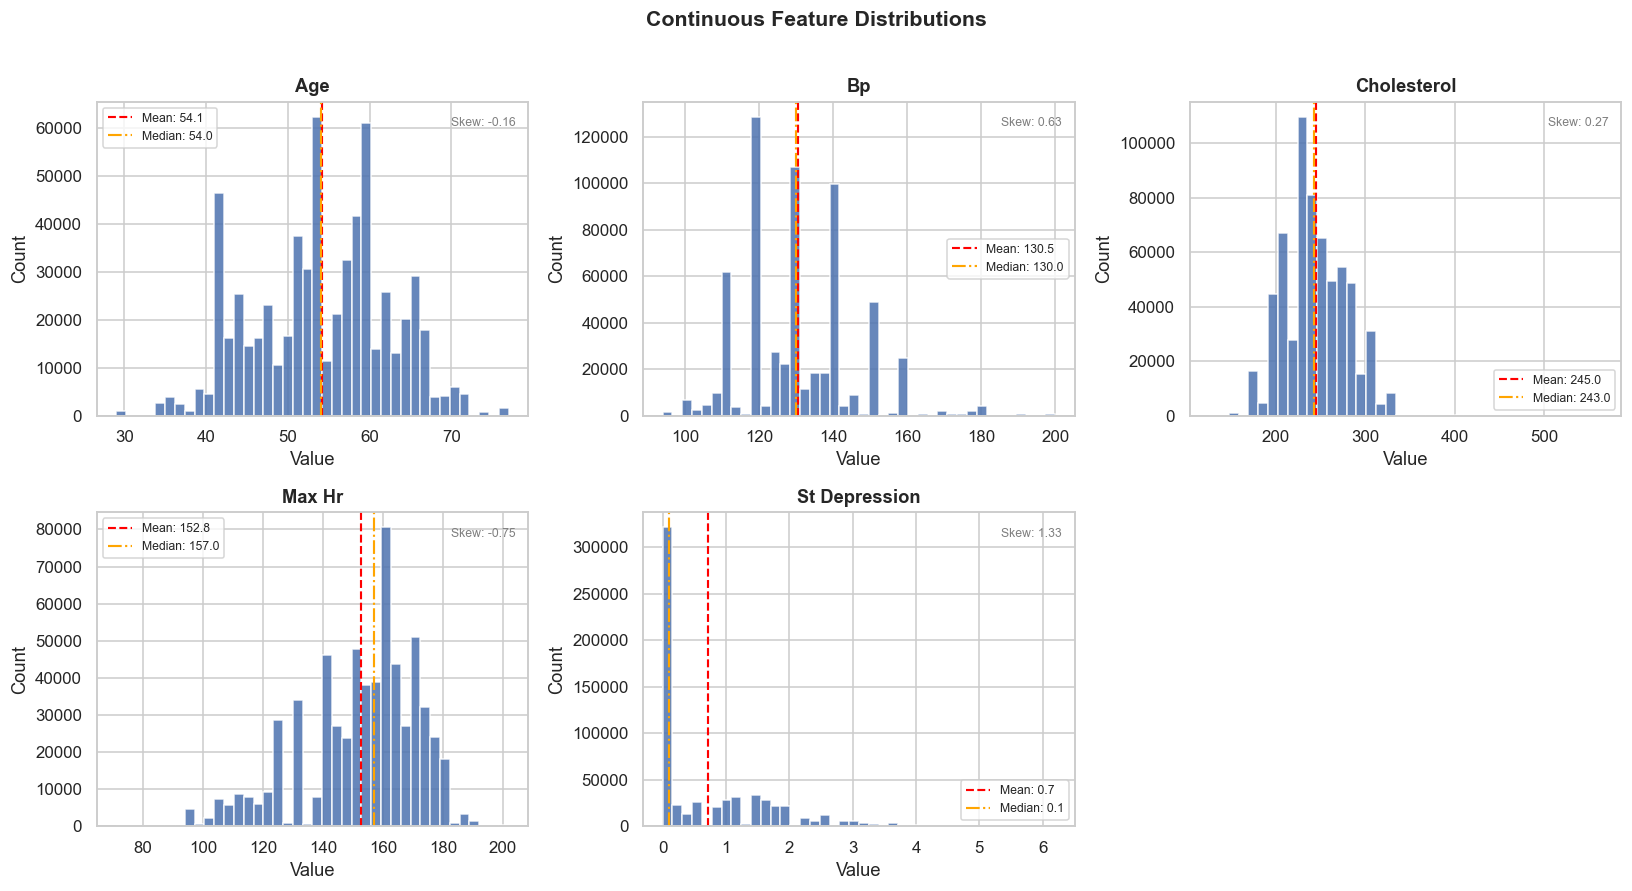

In [9]:
continuous_features = ["age", "bp", "cholesterol", "max_hr", "st_depression"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.4, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle="-.", linewidth=1.4, label=f"Median: {data.median():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    # Skewness annotation
    skew = data.skew()
    ax.text(0.97, 0.95, f"Skew: {skew:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="gray")

axes[-1].set_visible(False)  # hide unused subplot
plt.suptitle("Continuous Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4b. Categorical / Ordinal Features

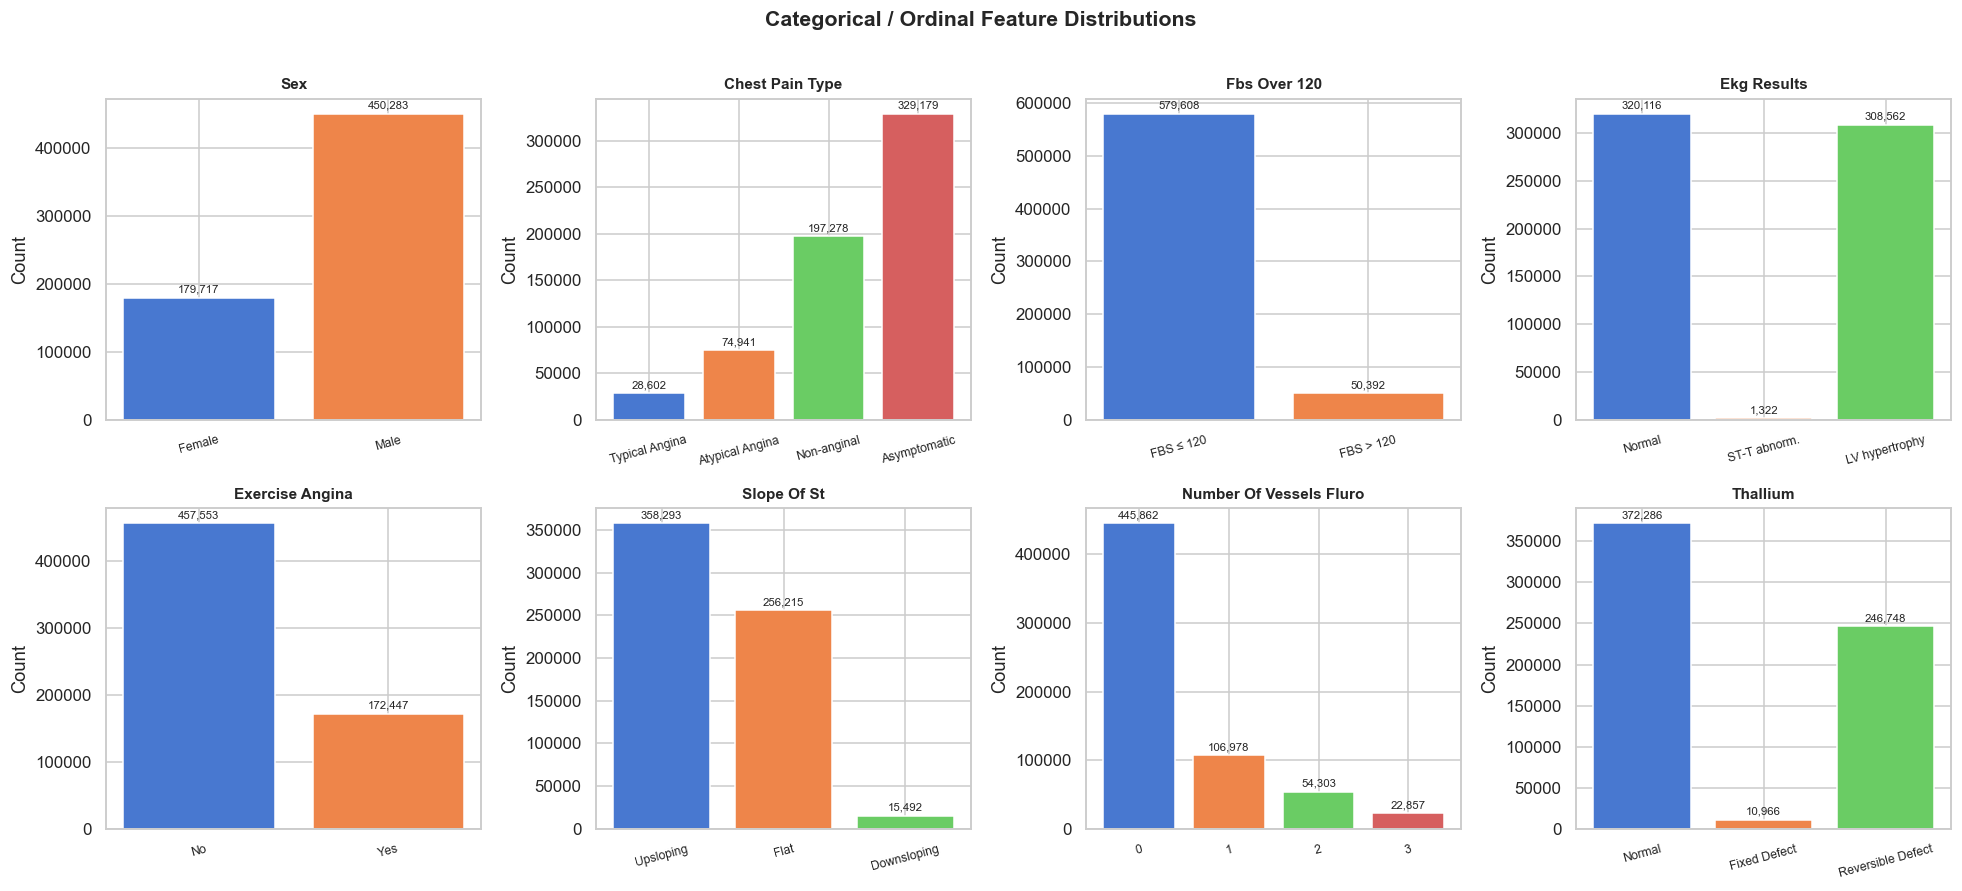

In [10]:
categorical_features = {
    "sex":                  {0: "Female", 1: "Male"},
    "chest_pain_type":      {1: "Typical Angina", 2: "Atypical Angina", 3: "Non-anginal", 4: "Asymptomatic"},
    "fbs_over_120":         {0: "FBS ≤ 120", 1: "FBS > 120"},
    "ekg_results":          {0: "Normal", 1: "ST-T abnorm.", 2: "LV hypertrophy"},
    "exercise_angina":      {0: "No", 1: "Yes"},
    "slope_of_st":          {1: "Upsloping", 2: "Flat", 3: "Downsloping"},
    "number_of_vessels_fluro": {0: "0", 1: "1", 2: "2", 3: "3"},
    "thallium":             {3: "Normal", 6: "Fixed Defect", 7: "Reversible Defect"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, label_map) in enumerate(categorical_features.items()):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    labels = [label_map.get(k, str(k)) for k in counts.index]
    bars = ax.bar(labels, counts.values, color=sns.color_palette("muted", len(counts)),
                  edgecolor="white", linewidth=1)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Categorical / Ordinal Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis <a id="5"></a>

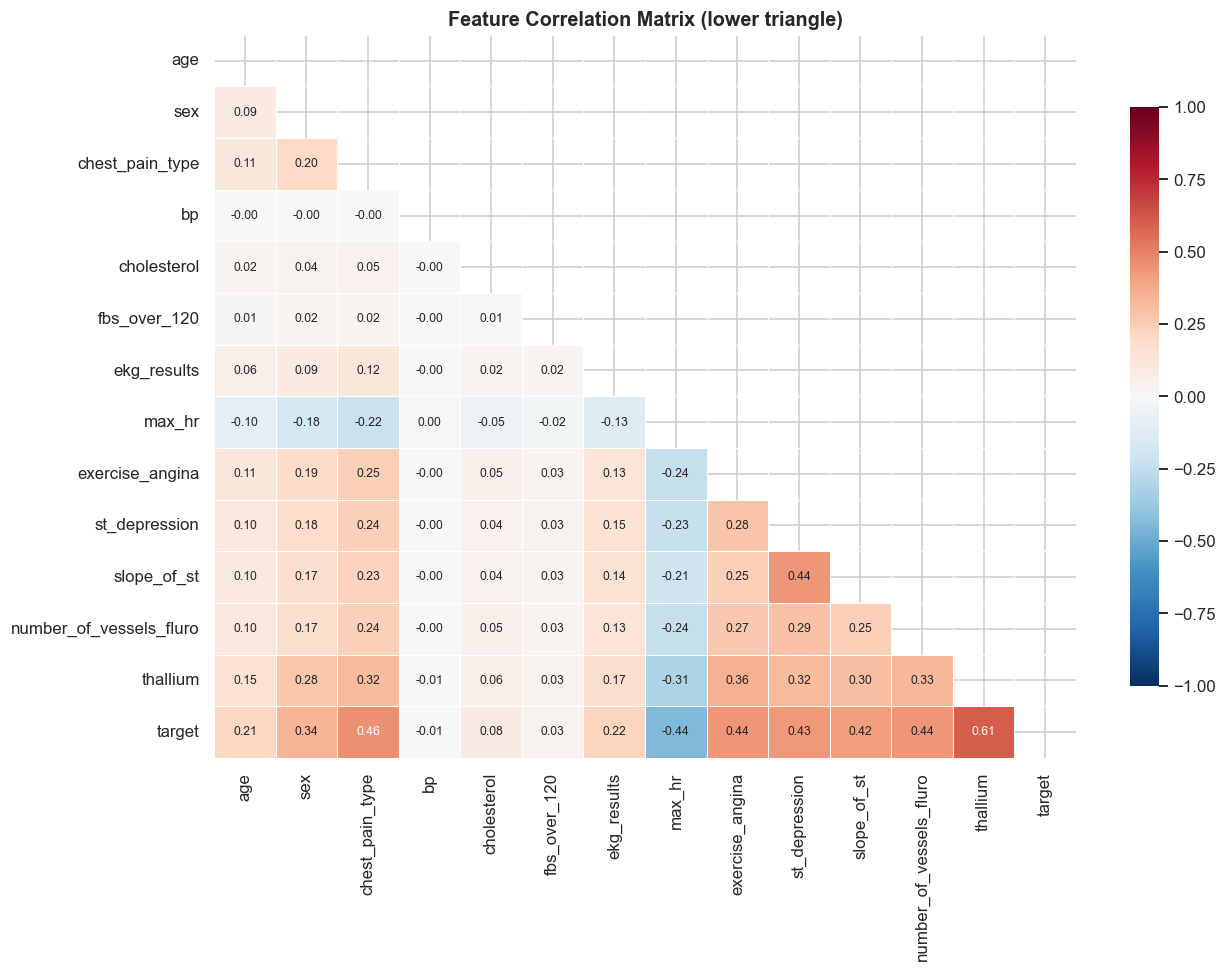

In [11]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "id"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

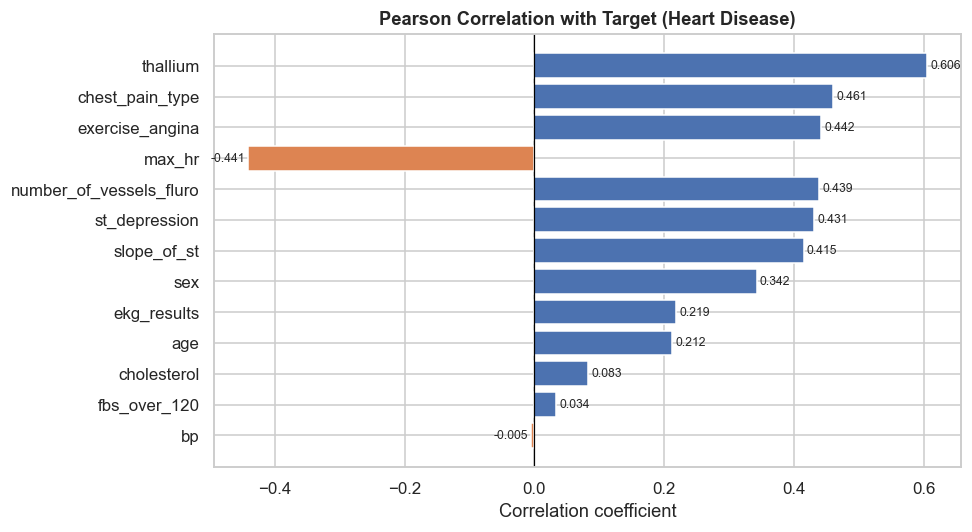

In [12]:
# Correlation with target — ranked bar chart
target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#4C72B0" if v > 0 else "#DD8452" for v in target_corr.values]
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors_bar[::-1],
               edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Target (Heart Disease)", fontweight="bold")
ax.set_xlabel("Correlation coefficient")
for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Bivariate Analysis — Features vs Target <a id="6"></a>

### 6a. Continuous Features vs Target (Box plots)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9108\835438728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="heart_disease", y=col, palette={"Absence": "#4C72B0", "Presence": "#DD8452"},
C:\Users\Admin\AppData\Local\Temp\ipykernel_9108\835438728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="heart_disease", y=col, palette={"Absence": "#4C72B0", "Presence": "#DD8452"},
C:\Users\Admin\AppData\Local\Temp\ipykernel_9108\835438728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="heart_dise

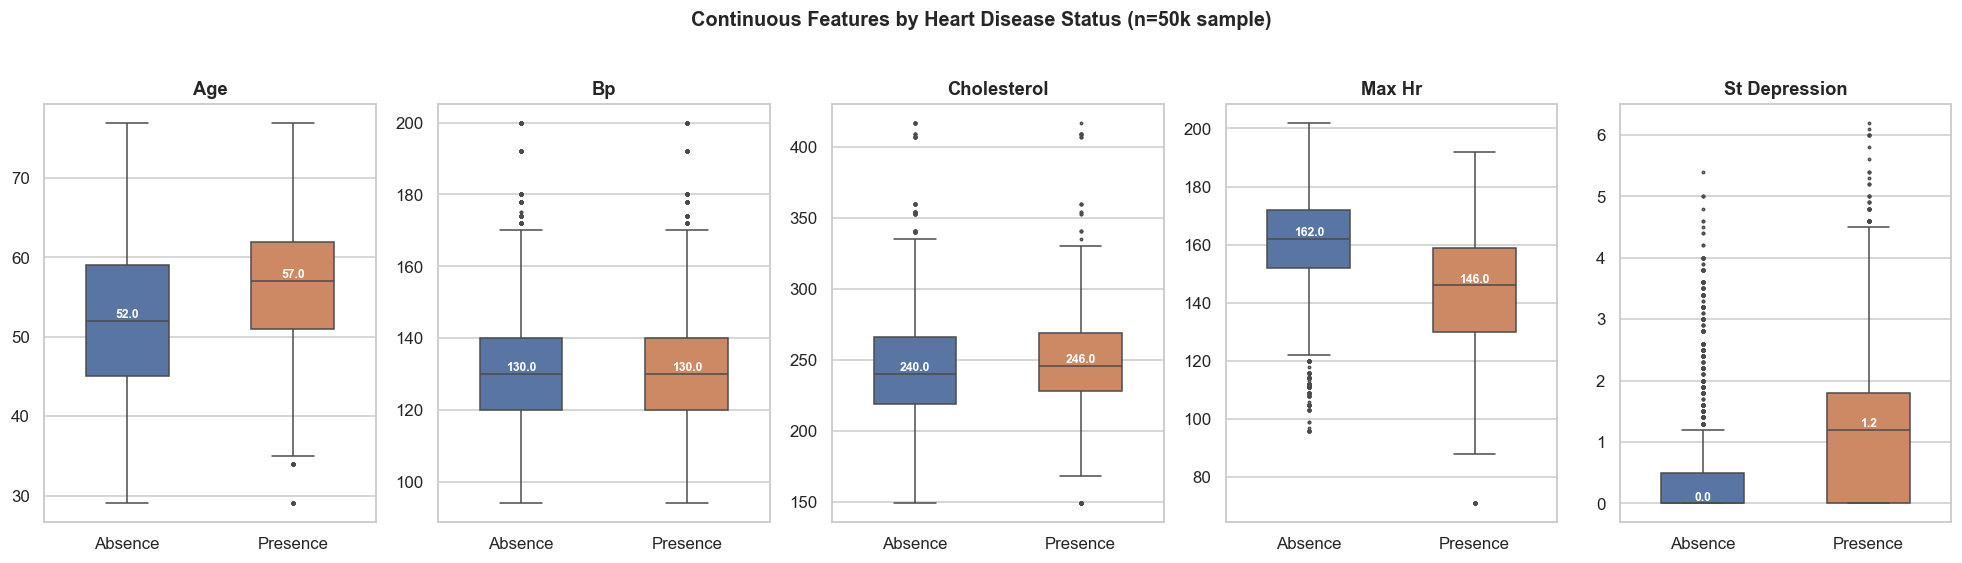

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, continuous_features):
    # Sample for speed on large dataset
    sample = df.sample(n=min(50_000, len(df)), random_state=42)
    sns.boxplot(data=sample, x="heart_disease", y=col, palette={"Absence": "#4C72B0", "Presence": "#DD8452"},
                width=0.5, linewidth=1, fliersize=1.5, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Annotate medians
    for i, group in enumerate(["Absence", "Presence"]):
        med = sample[sample["heart_disease"] == group][col].median()
        ax.text(i, med, f"{med:.1f}", ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")

plt.suptitle("Continuous Features by Heart Disease Status (n=50k sample)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6b. Categorical Features vs Target (stacked bar %)

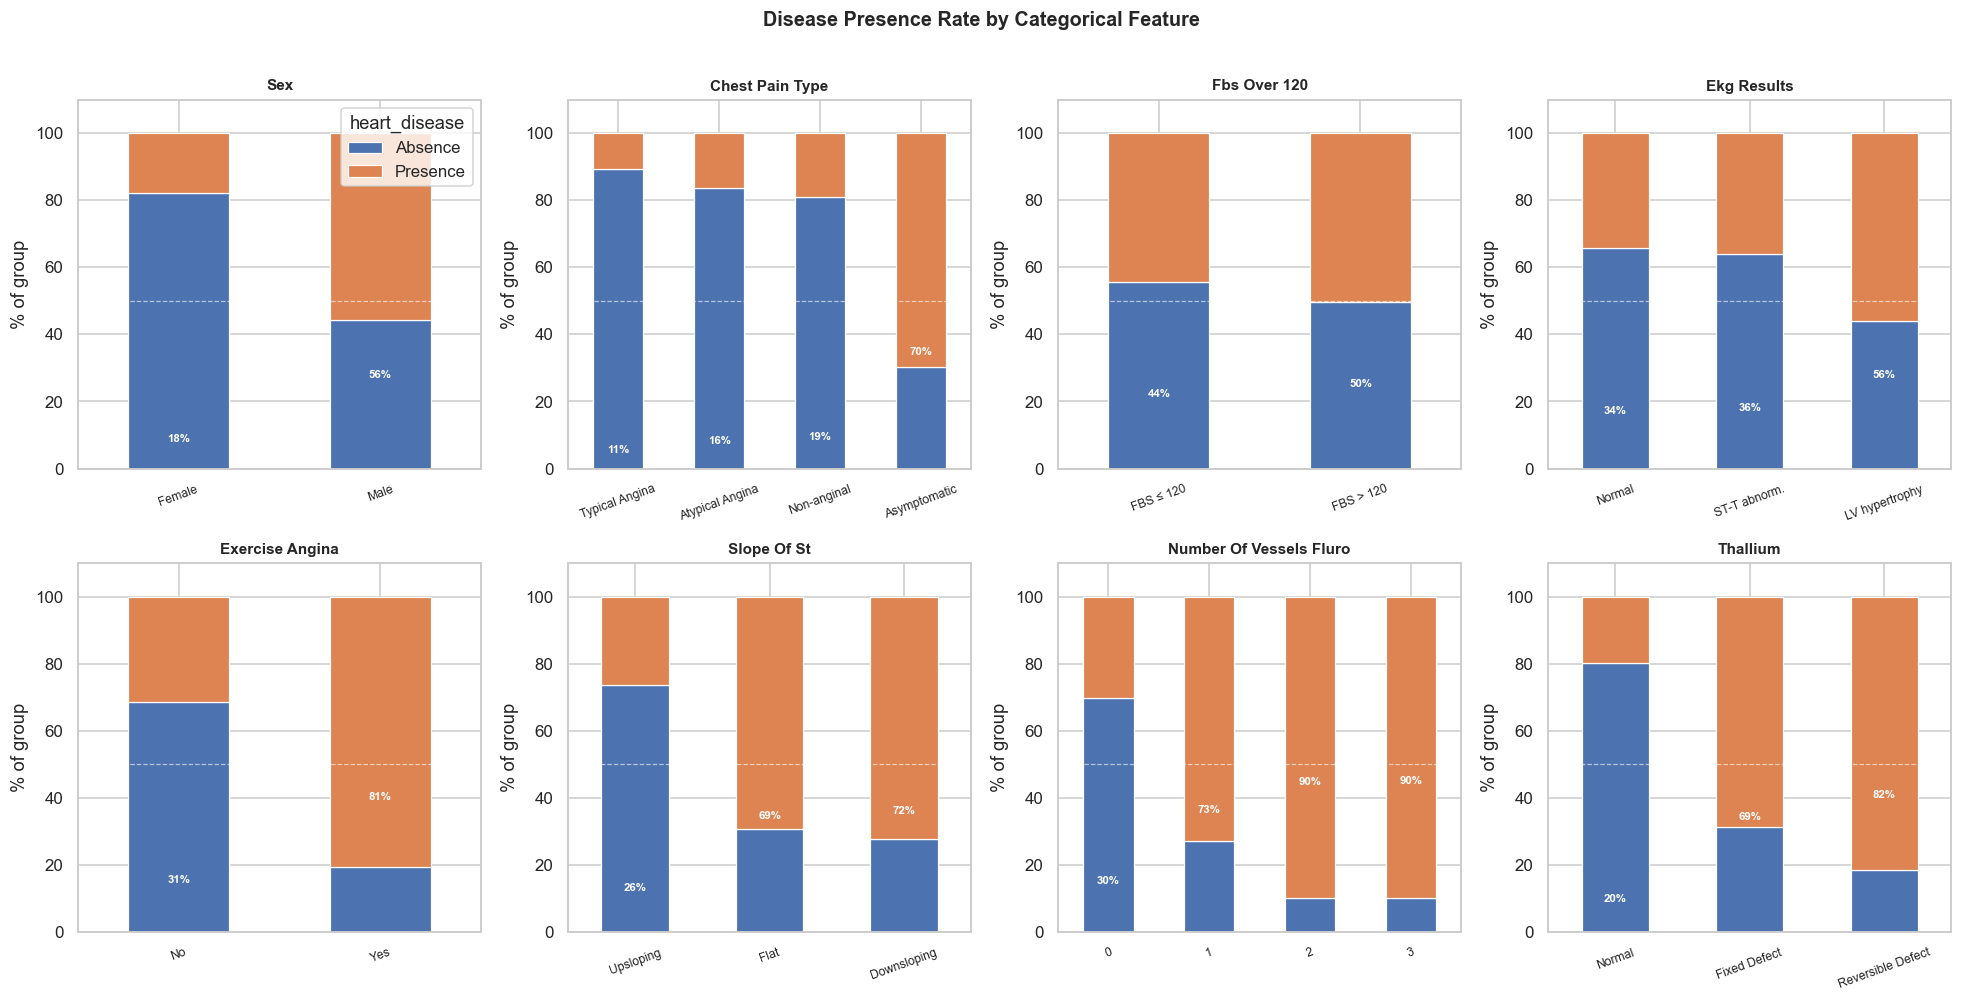

In [14]:
cat_cols = list(categorical_features.keys())
label_maps = categorical_features

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    lmap = label_maps[col]
    ct = pd.crosstab(df[col], df["heart_disease"], normalize="index") * 100
    ct.index = [lmap.get(k, str(k)) for k in ct.index]

    ct[["Absence", "Presence"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8, legend=(i == 0)
    )
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("% of group")
    ax.set_ylim(0, 110)
    ax.axhline(50, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    # Annotate Presence %
    for j, (idx, row) in enumerate(ct.iterrows()):
        pct = row.get("Presence", 0)
        ax.text(j, pct / 2, f"{pct:.0f}%", ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold")

plt.suptitle("Disease Presence Rate by Categorical Feature", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6c. Age × Max HR scatter (sample) — coloured by target

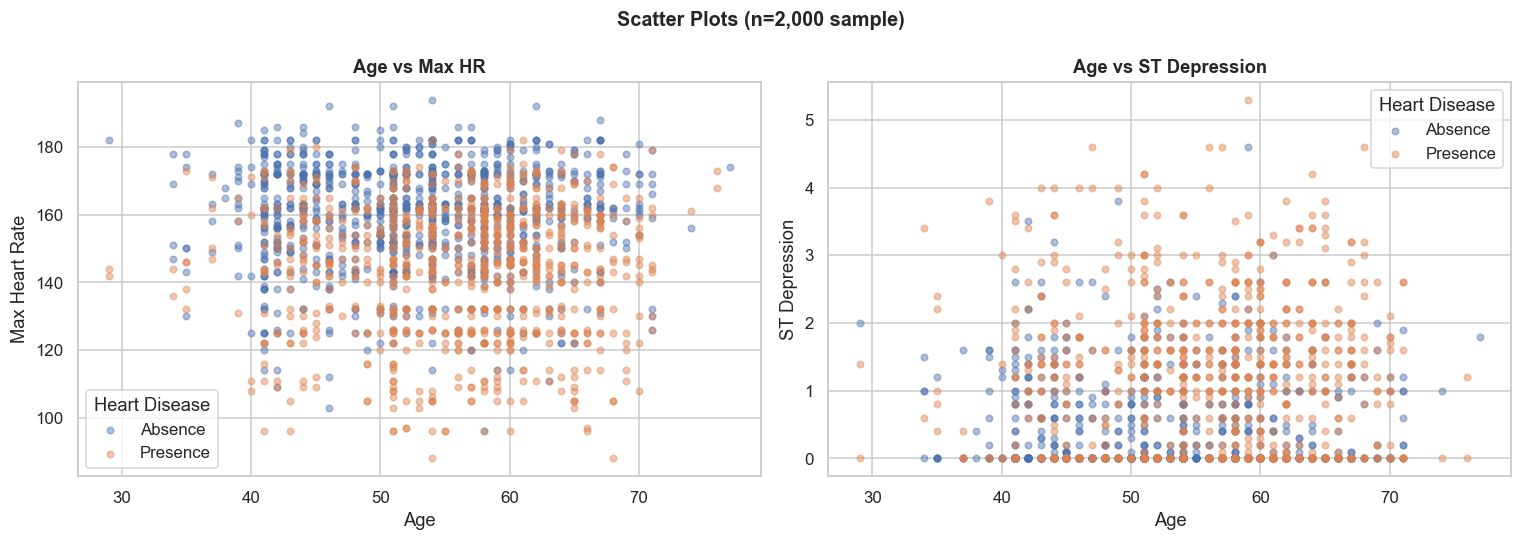

In [15]:
sample2k = df.sample(n=2000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Max HR
for label, color in [("Absence", "#4C72B0"), ("Presence", "#DD8452")]:
    sub = sample2k[sample2k["heart_disease"] == label]
    axes[0].scatter(sub["age"], sub["max_hr"], alpha=0.45, s=18, label=label, color=color)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Max Heart Rate")
axes[0].set_title("Age vs Max HR", fontweight="bold")
axes[0].legend(title="Heart Disease")

# Age vs ST Depression
for label, color in [("Absence", "#4C72B0"), ("Presence", "#DD8452")]:
    sub = sample2k[sample2k["heart_disease"] == label]
    axes[1].scatter(sub["age"], sub["st_depression"], alpha=0.45, s=18, label=label, color=color)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("ST Depression")
axes[1].set_title("Age vs ST Depression", fontweight="bold")
axes[1].legend(title="Heart Disease")

plt.suptitle("Scatter Plots (n=2,000 sample)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Outlier Detection <a id="7"></a>

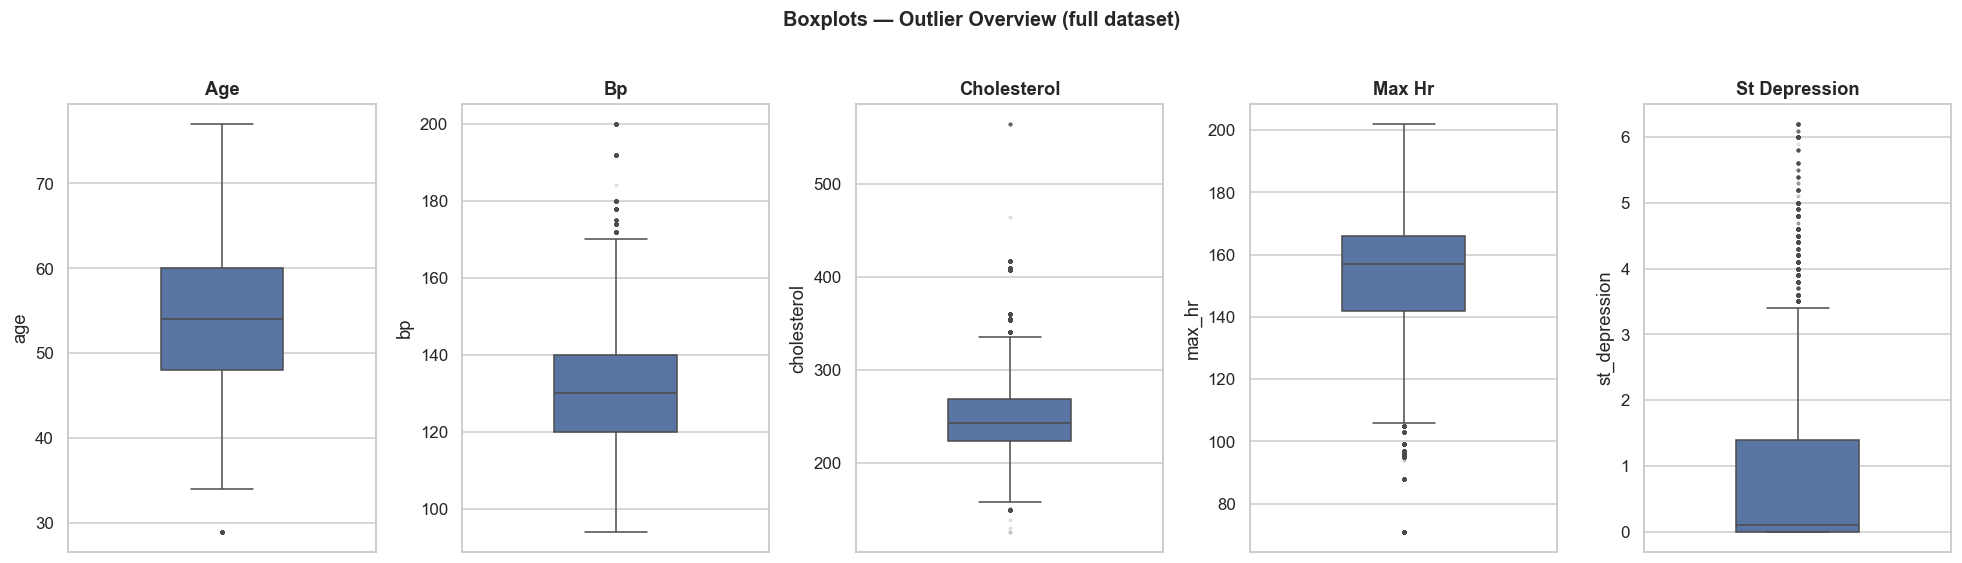

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, continuous_features):
    sns.boxplot(y=df[col], color="#4C72B0", width=0.4, fliersize=1.5,
                linewidth=1, flierprops={"alpha": 0.2}, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Boxplots — Outlier Overview (full dataset)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# IQR-based outlier count per feature
print("=== IQR Outlier Counts ===")
outlier_summary = []
for col in continuous_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower_fence": lower, "upper_fence": upper,
        "n_outliers": n_out, "%_outliers": round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary).set_index("feature")

=== IQR Outlier Counts ===


,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,%_outliers
feature,,,,,,,
age,48.00,60.00,12.00,30.00,78.00,1048,0.17
bp,120.00,140.00,20.00,90.00,170.00,9011,1.43
cholesterol,223.00,269.00,46.00,154.00,338.00,2194,0.35
max_hr,142.00,166.00,24.00,106.00,202.00,14246,2.26
st_depression,0.00,1.40,1.40,-2.10,3.50,9971,1.58


## 8. Key EDA Takeaways <a id="8"></a>

**Dataset:** 630,000 rows, 14 features, binary target (`Presence` / `Absence`).

**Class balance:** Check the target plot above — note if there is significant imbalance (which would require SMOTE/class weighting in modelling).

**Strongest predictors (from correlation & bivariate analysis):**
- `chest_pain_type` — Asymptomatic type is overwhelmingly associated with Presence
- `thallium` — Reversible defect strongly linked to disease
- `number_of_vessels_fluro` — Higher vessel count → higher risk
- `exercise_angina` — Exercise-induced angina is a strong positive signal
- `st_depression` — Higher depression at rest → more risk
- `max_hr` — Lower max HR associated with Presence
- `slope_of_st` — Flat/downsloping linked to disease

**Continuous feature distributions:**
- `age`: roughly normal, centred ~54 years
- `bp` and `cholesterol`: right-skewed; some high outliers
- `st_depression`: heavily right-skewed with many zero values

**Outliers:** `cholesterol` and `bp` have the most IQR outliers — consider capping or log-transforming before modelling.

**No missing values** detected (verify with sense check output above).

**Next steps:** Pre-processing → feature encoding → train/test split → model selection → evaluation.